Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3850.770, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3847.275, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3845.304, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3845.198, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3847.820, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3846.999, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=3846.901, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3848.895, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=3845.134, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=3846.903, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=3847.001, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=3845.265, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=3848.772, Time=0.09 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.731 seconds
📈 ARIMA MAE: 568.49 US

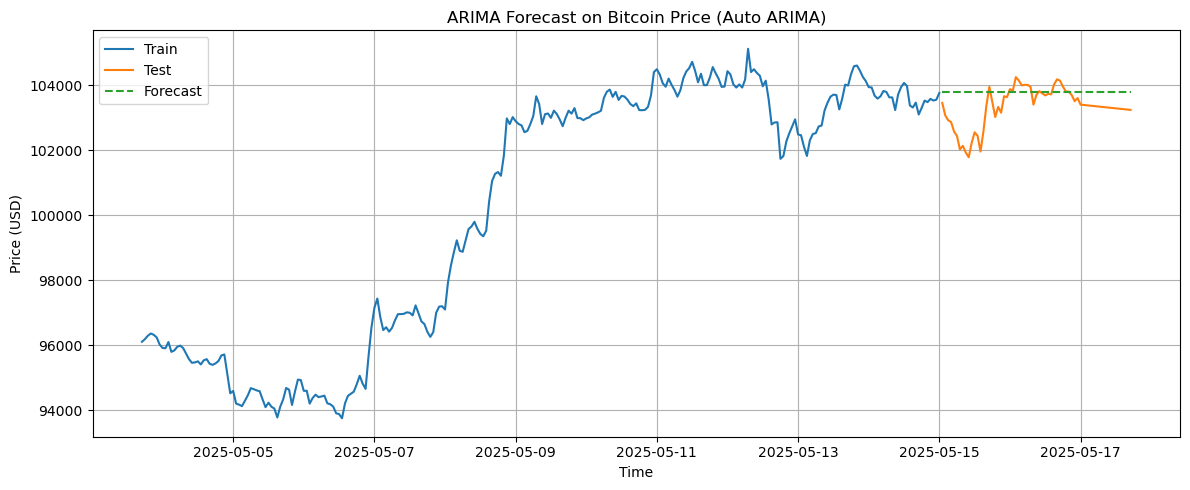

✅ ARIMA forecast saved.


In [2]:
# 07_arima_modeling.ipynb
# ARIMA Forecasting for Bitcoin Time Series using auto_arima

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Monkey patch for scikit-learn < 1.6 compatibility workaround
import sklearn.utils.validation
if hasattr(sklearn.utils.validation, 'force_all_finite'):
    sklearn.utils.validation.ensure_all_finite = sklearn.utils.validation.force_all_finite

# --- 1. Load and Prepare Data ---
df = pd.read_csv("../data/bitcoin_timeseries.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

# Resample to hourly average
df_hourly = df['price_usd'].resample('1h').mean().dropna()

# Use last N days
days_to_use = 14
hourly_cutoff = df_hourly.index.max() - pd.Timedelta(days=days_to_use)
df_hourly = df_hourly[df_hourly.index >= hourly_cutoff]

# --- 2. Train-Test Split ---
train_size = int(len(df_hourly) * 0.85)
train, test = df_hourly.iloc[:train_size], df_hourly.iloc[train_size:]

# --- 3. Auto ARIMA Model Selection ---
model = auto_arima(train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

# --- 4. Forecast ---
forecast = model.predict(n_periods=len(test))

# --- 5. Evaluate ---
mae = mean_absolute_error(test, forecast)
rmse = mean_squared_error(test, forecast) ** 0.5  # use square root manually for compatibility
print(f"📈 ARIMA MAE: {mae:.2f} USD")
print(f"📈 ARIMA RMSE: {rmse:.2f} USD")

# --- 6. Plot ---
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.title("ARIMA Forecast on Bitcoin Price (Auto ARIMA)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../reports/arima_forecast.png")
plt.show()

# --- 7. Optional: Save Forecast to CSV ---
df_forecast = pd.DataFrame({
    'timestamp': test.index,
    'actual_price': test.values,
    'predicted_price': forecast
})
df_forecast.to_csv("../data/bitcoin_arima_forecast.csv", index=False)
print("✅ ARIMA forecast saved.")